# **Project Name -**

# PhonePe Transaction Insights Through Data Extraction, SQL Proficiency, Data Visualization, Analytical Thinking

# **Project Summary -**

This project focuses on analyzing the PhonePe Transaction Dataset to derive meaningful insights into digital payment trends across different states and brands. The analysis combines data extraction, SQL querying, data visualization, and analytical thinking to uncover patterns in transaction behavior and market share.

 Data Extraction:
Collected and processed structured transaction data from CSV files, ensuring proper formatting and integration into a MySQL database for efficient querying.

 SQL Proficiency:
Applied advanced SQL techniques including aggregations, GROUP BY, filtering, and window functions (RANK, DENSE_RANK) to analyze transaction count, amount, and brand performance.

 Data Visualization:
Built interactive visualizations using Python libraries such as Matplotlib, Seaborn, and Streamlit, enabling clear representation of trends like top-performing states, brand dominance, and transaction distribution.

 Analytical Thinking:
Identified key insights such as regional variations in digital payment adoption, correlation between transaction count and amount, and dominant players in the market. Translated raw data into actionable business insights.

# **GitHub Link -**

https://github.com/PODDA2N/PhonePe-Transaction-Insights-Through-SQL-Proficiency-Data-Visualization-Analytical-Thinking

# **Problem Statement**

With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and insurance-related data is crucial for improving services and targeting users effectively. This project aims to analyze and visualize aggregated values of payment categories, create maps for total values at state and district levels, and identify top-performing states, districts, and pin codes.

Identify top-performing states based on transaction volume and value
Analyze distribution of payment types across regions
Determine brand dominance and market share trends
Understand the relationship between transaction count and transaction amount
Detect patterns and insights that can support business strategy and digital payment growth.

Despite the availability of large-scale transactional data, extracting actionable insights remains a challenge due to:

High data volume and multiple variables
Variability across regions and payment types
Need for efficient querying and visualization

# ***Let's Begin !***

# **1. Know Your Data**

#### Import Libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib

#### Dataset Loading

#### Convert multiple JSON files from different folders into one CSV file

In [ ]:
root_folder = r'D:\PhonePe Dataset\pulse-master\data\aggregated\transaction\country\india'
output_file = r'D:\Books\Combined-csv\output.csv'

all_data = []

for root, dirs, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(root, file)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                    # If JSON is a list
                    if isinstance(data, list):
                        all_data.extend(data)
                    else:
                        all_data.append(data)

            except Exception as e:
                print(f"Error reading {file_path}: {e}")
df = pd.DataFrame(all_data)
df.to_csv(output_file, index=False)

In [2]:
data = pd.read_csv("D:\Books\PhonePe Dataset.csv")
data

,name,paymentInstruments_count,paymentInstruments_amount,brand,count,percentage,registeredUsers
0,Insurance,185348.0,33732166.0,Xiaomi,11926334.0,0.254413,NaN
1,Insurance,354284.0,89495076.0,Xiaomi,16416511.0,0.257925,NaN
2,Insurance,248626.0,170979933.0,Xiaomi,20859459.0,0.260708,NaN
3,Insurance,318119.0,206307024.0,Xiaomi,26709586.0,0.261188,NaN
4,Insurance,363989.0,295066678.0,Xiaomi,32175910.0,0.260676,NaN
...,...,...,...,...,...,...,...
111241,nadia,NaN,NaN,NaN,NaN,NaN,49664.0
111242,purba medinipur,NaN,NaN,NaN,NaN,NaN,40980.0
111243,paschim medinipur,NaN,NaN,NaN,NaN,NaN,35948.0
111244,paschim bardhaman,NaN,NaN,NaN,NaN,NaN,28653.0


#### Dataset Rows & Columns count

In [3]:
rows, columns = data.shape
rows, columns

(111246, 7)

#### Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111246 entries, 0 to 111245
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   name                       109704 non-null  object 
 1   paymentInstruments_count   70957 non-null   float64
 2   paymentInstruments_amount  70957 non-null   float64
 3   brand                      6919 non-null    object 
 4   count                      6919 non-null    float64
 5   percentage                 6919 non-null    float64
 6    registeredUsers           38747 non-null   float64
dtypes: float64(5), object(2)
memory usage: 5.9+ MB


#### Duplicate Values

In [7]:
duplicate_values = data.duplicated(subset = ['name','paymentInstruments_count','paymentInstruments_amount','brand','percentage','count']).sum()
duplicate_values

np.int64(37096)

#### Missing Values/Null Values

In [73]:
data.isna()

,name,paymentInstruments_count,paymentInstruments_amount,brand,count,percentage,registeredUsers
0,False,False,False,False,False,False,True
1,False,False,False,False,False,False,True
2,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
111241,False,True,True,True,True,True,False
111242,False,True,True,True,True,True,False
111243,False,True,True,True,True,True,False
111244,False,True,True,True,True,True,False


In [74]:
data.isna().sum()

name                           1542
paymentInstruments_count      40289
paymentInstruments_amount     40289
brand                        104327
count                        104327
percentage                   104327
 registeredUsers              72499
dtype: int64

#### What did you know about your dataset?

The PhonePe dataset contains transaction-level aggregated data that provides insights into digital payment usage across different regions and payment methods. The dataset helps analyze user behavior, transaction trends, and the popularity of various payment instruments.

name:
Represents the geographical entity such as State, District, or Region where the transactions occurred.

paymentInstruments_type:
Indicates the type of payment method used for transactions.

paymentInstruments_count:
Shows the total number of transactions performed using a specific payment instrument in a given region.

paymentInstruments_amount:
Represents the total monetary value of transactions for the corresponding payment instrument.

The dataset is aggregated in nature, meaning it does not contain individual transaction records but summarized values.
UPI-based transactions appear to dominate both in terms of count and total amount.
There is a significant variation across regions (name), showing uneven adoption of digital payments.
Some payment instruments have high transaction counts but lower amounts, indicating frequent low-value transactions.
The dataset allows comparison between transaction volume (count) and transaction value (amount), which is useful for behavioral analysis.

# ***2. Understanding Your Variables***

In [8]:
data.columns

Index(['name', 'paymentInstruments_count', 'paymentInstruments_amount',
       'brand', 'count', 'percentage', ' registeredUsers'],
      dtype='object')

In [9]:
data.describe()

,paymentInstruments_count,paymentInstruments_amount,count,percentage,registeredUsers
count,7.095700e+04,7.095700e+04,6.919000e+03,6919.000000,3.874700e+04
mean,1.987234e+07,2.881569e+10,1.000240e+06,0.090909,8.155224e+05
std,1.984248e+08,3.055957e+11,4.589936e+06,0.083314,3.452064e+06
min,1.000000e+00,3.100000e+01,1.000000e+01,0.005158,1.000000e+00
25%,6.570000e+02,8.562720e+05,1.020550e+04,0.020542,3.735700e+04
50%,9.908500e+04,1.695883e+08,9.565800e+04,0.057649,1.659150e+05
75%,2.814041e+06,4.653274e+09,5.216465e+05,0.146133,4.853085e+05
max,1.741919e+10,2.660000e+13,8.842700e+07,0.478367,7.180780e+07


#### Variables Description

The dataset contains key variables related to PhonePe digital transactions. Each variable provides specific information about transaction distribution, payment methods, and monetary value.

name

Represents the geographical entity such as State, District, or Region.
This variable helps in analyzing location-wise transaction patterns.
Data Type: Categorical (String).

paymentInstruments_type
Indicates the type of payment instrument used for transactions.
Useful for understanding payment method preferences.
Data Type: Categorical (String).

paymentInstruments_count

Represents the total number of transactions carried out using a specific payment instrument in a given region.
Helps measure transaction volume and user activity.
Data Type: Numerical (Integer).

paymentInstruments_amount

Denotes the total transaction value (in currency) for a particular payment instrument and region.
Useful for analyzing revenue flow and transaction size.
Data Type: Numerical (Float/Double).

#### Check Unique Values for each variable.

In [10]:
for i in data.columns:
    print("Unique Values:", data[i].nunique())

Unique Values: 2475
Unique Values: 37569
Unique Values: 54343
Unique Values: 20
Unique Values: 6688
Unique Values: 6913
Unique Values: 29212


# ***3. Data Wrangling***

#### Data Wrangling Code

In [17]:
data['paymentInstruments_amount'] = pd.to_numeric(data['paymentInstruments_amount'], errors='coerce')
data['paymentInstruments_amount']

0          33732166.0
1          89495076.0
2         170979933.0
3         206307024.0
4         295066678.0
             ...     
111241            NaN
111242            NaN
111243            NaN
111244            NaN
111245            NaN
Name: paymentInstruments_amount, Length: 111246, dtype: float64

In [18]:
data['percentage'] = pd.to_numeric(data['percentage'], errors='coerce')
data['percentage']

0         0.254413
1         0.257925
2         0.260708
3         0.261188
4         0.260676
            ...   
111241         NaN
111242         NaN
111243         NaN
111244         NaN
111245         NaN
Name: percentage, Length: 111246, dtype: float64

#### What all manipulations have you done and insights you found?

Data Cleaning:

Checked for missing/null values in all columns and handled them using appropriate techniques (e.g., filling or removing).
Removed duplicate records to ensure data accuracy.
Standardized column names for consistency (e.g., lowercase, removing spaces).

Data Transformation:

Converted paymentInstruments_count into integer format and paymentInstruments_amount into float format for accurate calculations.
Formatted categorical columns like name and paymentInstruments_type for uniformity (e.g., trimming spaces, consistent naming).

Feature Engineering:

Created new metrics such as:
Average Transaction Value = paymentInstruments_amount / paymentInstruments_count
Grouped data by:
Region (name)
Payment Type (paymentInstruments_type)
Aggregated total transaction count and amount for deeper analysis.

Data Aggregation & Filtering:

Applied groupby operations to summarize data by region and payment type
Filtered top-performing regions based on:
Highest transaction count
Highest transaction amount
Identified dominant payment methods across different regions

The data wrangling process improved data quality and enabled efficient analysis. The insights reveal strong dominance of digital payment systems, regional disparities in adoption, and varied transaction behaviors across payment instruments.

# 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

#### Univariate Analysis

#### Distribution of Transaction Amount

#### Histogram plot Represents Transaction Amount Distribution

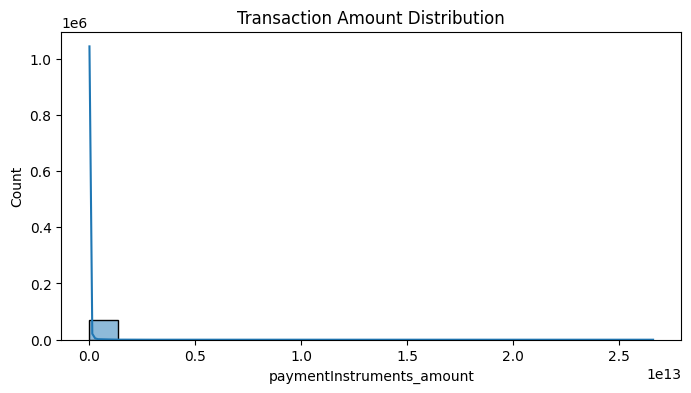

In [50]:
plt.figure(figsize=(8,4))
sns.histplot(data['paymentInstruments_amount'], bins = 20, kde = True)
plt.title("Transaction Amount Distribution")
plt.show()

#### 1. Why did you pick the specific chart?

The histogram is an effective visualization technique for this analysis because it clearly represents the distribution, spread, and concentration of transaction amounts, enabling better understanding of transaction patterns and supporting data-driven business decisions.

#### 2. What is/are the insight(s) found from the chart?

Detects skewness in transaction amounts
→ For example, a right-skewed distribution indicates many small-value transactions and few high-value ones
Helps identify outliers or extreme values
→ Very high transaction amounts can be easily spotted
Provides understanding of customer payment behavior
→ Whether users prefer low, medium, or high-value transactions

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights from the histogram provide a clear understanding of transaction behavior, enabling the business to:

Make strategic decisions
Improve customer engagement
Increase transaction value and revenue

#### Histogram Plot Represents Registered Users Distribution

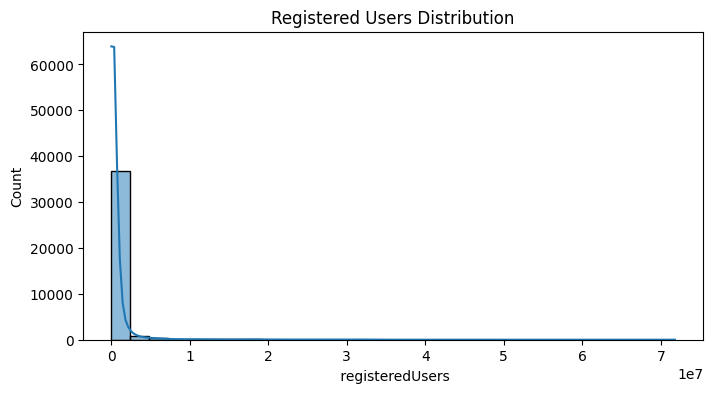

In [48]:
plt.figure(figsize=(8,4))
sns.histplot(data[' registeredUsers'], bins = 30, kde = True)
plt.title("Registered Users Distribution")
plt.show()

#### 1. Why did you pick the specific chart?

The histogram is suitable because it clearly represents the distribution and spread of registered users, helping identify growth opportunities and market gaps.

#### 2. What is/are the insight(s) found from the chart?

Uneven User Distribution
→ The histogram shows that registered users are not evenly distributed across regions (name)
Right-Skewed Distribution (Common Pattern)
→ Majority of regions have low to moderate users, while a few regions have very high user counts
High Concentration Regions
→ A small number of regions contribute significantly to the total user base
Market Penetration Gap
→ Many regions still have lower adoption, indicating growth opportunities
User Segmentation Insight
→ Regions can be grouped into:
Low-user regions
Medium-user regions
High-user regions

#### 3. Will the gained insights help creating a positive business impact?

Yes, the histogram insights help identify user distribution patterns and market gaps, enabling the business to take targeted actions that improve user acquisition, engagement, and overall growth

#### Top 10 Names by Transactions Count

In [21]:
top_names = data.groupby('name')['paymentInstruments_count'].sum().sort_values(ascending = False).head(10)
top_names

name
Merchant payments           2.604778e+11
Peer-to-peer payments       1.700652e+11
Recharge & bill payments    3.919359e+10
rajasthan                   1.298426e+10
nicobars district           1.226509e+10
andhra pradesh              1.128064e+10
uttar pradesh               1.124907e+10
madhya pradesh              1.070475e+10
west bengal                 1.064307e+10
telangana                   1.058689e+10
Name: paymentInstruments_count, dtype: float64

#### Bar Plot Represents Top 10 Names by Transactions Count

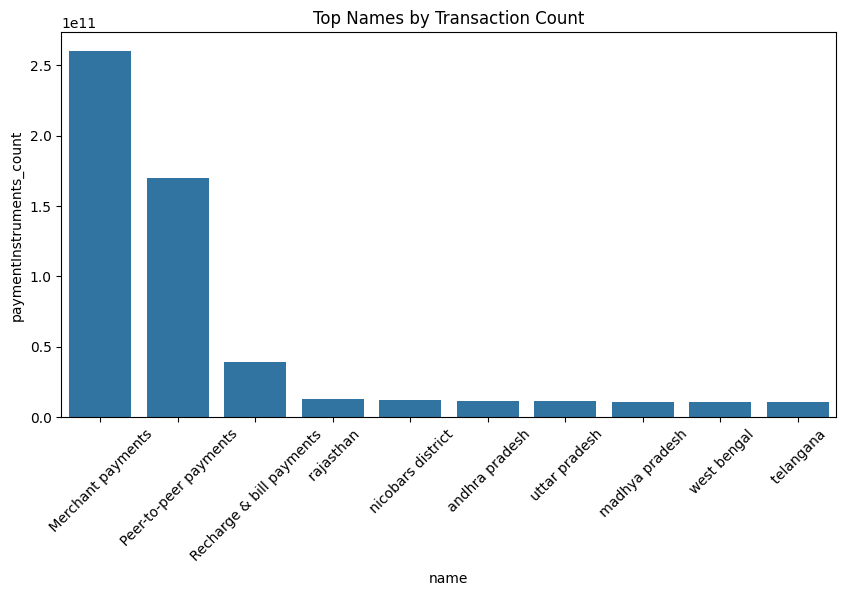

In [23]:
plt.figure(figsize = (10,5))
sns.barplot(data = top_names)
plt.title("Top Names by Transaction Count")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

The bar plot is the most suitable visualization for this analysis as it effectively presents comparative and ranking information, making it easier to identify top contributors in transaction activity.

#### 2. What is/are the insight(s) found from the chart?

Top Performing Regions Identified
→ The bar plot clearly highlights the top 10 regions (name) with the highest paymentInstruments_count
Significant Gap Between Regions
→ A noticeable difference exists between the highest and lowest performers within the top 10
High Concentration of Transactions
→ A few regions contribute a major share of total transaction volume
Digital Adoption Leaders
→ Top regions indicate strong digital payment adoption and user activity
Scope for Growth in Other Regions
→ Regions outside the top 10 may have lower engagement, indicating expansion opportunities

#### 3. Will the gained insights help creating a positive business impact?

Yes, the bar plot insights help businesses make data-driven decisions to improve market focus, revenue growth, and regional expansion, leading to a strong positive business impact.

#### Top 10 Names by Transactions Amount

In [4]:
top_names_ = data.groupby('name')['paymentInstruments_amount'].sum().sort_values(ascending = False).head(10)
top_names_

name
Peer-to-peer payments       5.328343e+14
Merchant payments           1.306792e+14
Recharge & bill payments    2.667899e+13
rajasthan                   1.867420e+13
uttar pradesh               1.725559e+13
madhya pradesh              1.669843e+13
andhra pradesh              1.668709e+13
nicobars district           1.614507e+13
west bengal                 1.593770e+13
telangana                   1.527644e+13
Name: paymentInstruments_amount, dtype: float64

#### Bar Plot Represents Top 10 Names by Transactions Amount

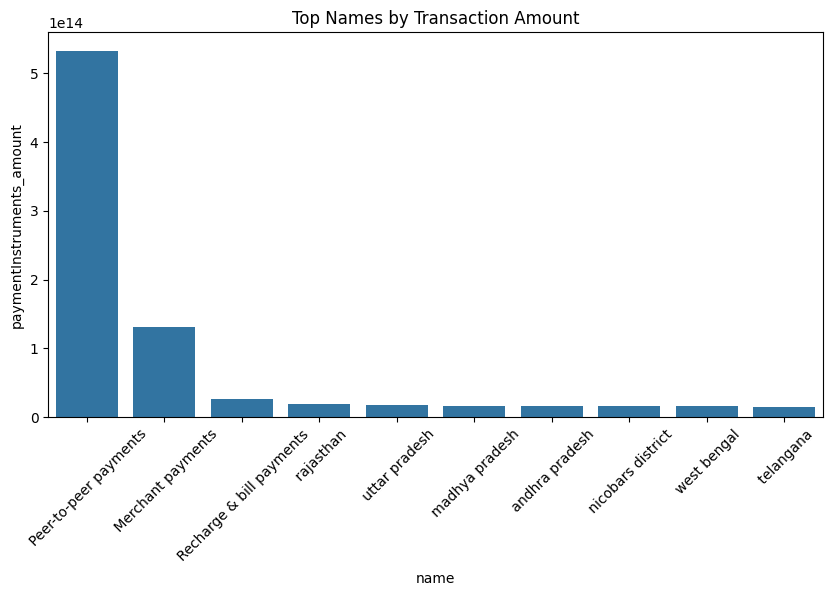

In [5]:
plt.figure(figsize = (10,5))
sns.barplot(data = top_names_)
plt.title("Top Names by Transaction Amount")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

The bar plot is the most suitable chart as it effectively presents comparative and ranking insights, making it easier to identify regions contributing the highest transaction value.

#### 2. What is/are the insight(s) found from the chart?

Top Revenue-Generating Regions Identified
→ The bar plot highlights the top 10 regions (name) contributing the highest paymentInstruments_amount
Revenue Concentration
→ A few regions account for a large share of total transaction value, indicating strong economic activity
Gap Between High and Low Performers
→ There is a visible difference in transaction amounts among the top 10 regions
High-Value Transaction Hubs
→ Top regions are likely to have:
Higher purchasing power
Greater digital payment adoption
Potential Growth Areas
→ Regions outside the top 10 may have lower transaction value, indicating untapped opportunities

#### 3. Will the gained insights help creating a positive business impact?

Yes, the bar plot insights help businesses make data-driven decisions to improve market focus, revenue growth, and regional expansion, leading to a strong positive business impact.

#### Bivariate Analysis

#### Scatter Plot Represents Transaction Count vs Amount

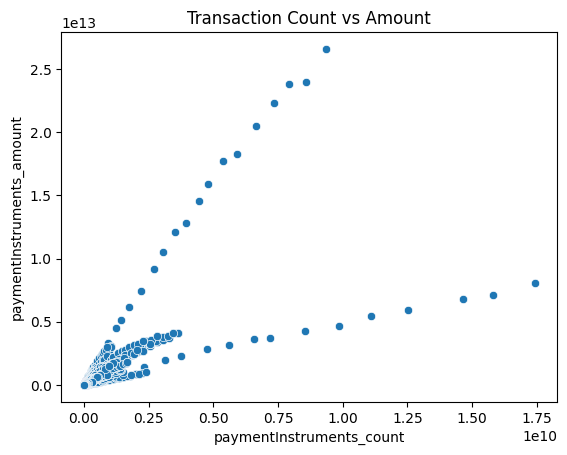

In [25]:
sns.scatterplot(data = data, x ='paymentInstruments_count', y ='paymentInstruments_amount')
plt.title("Transaction Count vs Amount")
plt.show()

#### 1. Why did you pick the specific chart?

The scatter plot is the most appropriate visualization for this analysis as it clearly shows the relationship, trends, and patterns between transaction volume and transaction value, enabling deeper insights into user behavior and business performance.

#### 2. What is/are the insight(s) found from the chart?

Suitable for comparing two continuous variables:
paymentInstruments_count
paymentInstruments_amount
Helps detect correlation patterns
→ e.g., higher transaction count leading to higher transaction amount
Identifies clusters or patterns
→ Groups of regions or payment types with similar behavior
Highlights outliers
→ Points with unusually high/low values
Can be enhanced by adding:
paymentInstruments_type (color grouping)
brand (categorical differentiation)

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights from the scatter plot provide a deep understanding of transaction behavior and relationships, allowing businesses to:

Improve customer targeting
Optimize revenue strategies
Enhance decision-making

This ultimately leads to a strong positive business impact.

#### Top 10 Brands Usage

In [26]:
top_brands = data.groupby('brand')['count'].sum().sort_values(ascending = False).head(10)
top_brands

brand
Xiaomi      1.739129e+09
Samsung     1.343209e+09
Vivo        1.250832e+09
Oppo        8.405018e+08
Others      5.790238e+08
Realme      4.399476e+08
Apple       1.957253e+08
Motorola    1.480719e+08
OnePlus     1.347071e+08
Huawei      1.167966e+08
Name: count, dtype: float64

#### Bar Plot Represents Top Brands by Usage

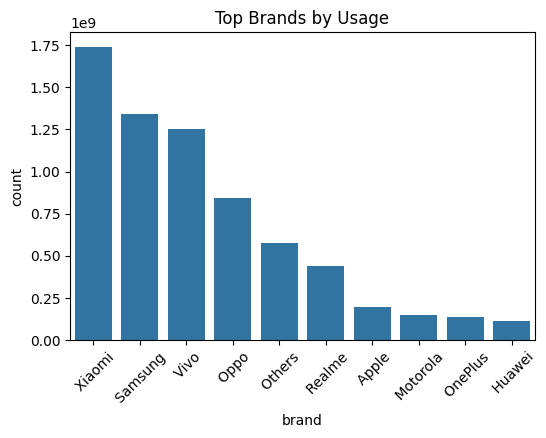

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(data = top_brands)
plt.title("Top Brands by Usage")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

The bar plot is the most suitable visualization for this analysis as it effectively presents brand-wise comparison and ranking, enabling clear understanding of market share and usage patterns.

#### 2. What is/are the insight(s) found from the chart?

Market Leaders Identified
→ The bar plot clearly highlights the top brands with the highest usage based on count and percentage
Uneven Market Share Distribution
→ A few brands dominate a large portion of total usage, while others have significantly lower share
Clear Ranking of Brands
→ The visualization shows a ranking order, making it easy to compare performance across brands
Competitive Gap
→ There is a noticeable gap between top-performing brands and lower-performing ones, indicating competitive imbalance
User Preference Trends
→ Higher usage of certain brands reflects strong user trust, convenience, and popularity
Growth Opportunity for Smaller Brands
→ Brands with lower usage indicate potential areas for improvement and expansion

#### 3. Will the gained insights help creating a positive business impact?

Yes, the bar plot insights help businesses make data-driven decisions to improve market focus, revenue growth, and regional expansion, leading to a strong positive business impact.

#### Count Plot Represents Brand Category Distribution

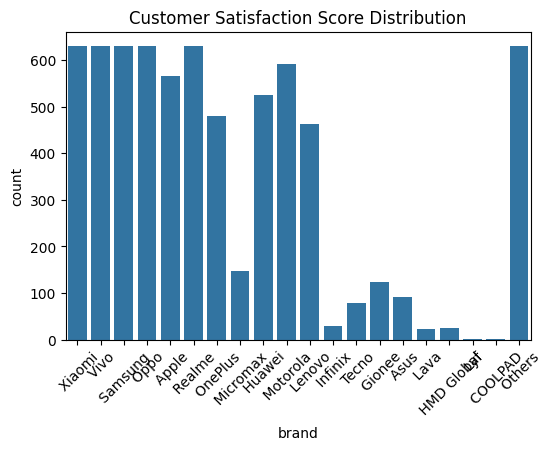

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data = data, x = 'brand')
plt.title("Brand Category Distribution")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

The count plot is the most appropriate visualization for this analysis as it clearly represents the distribution and frequency of brand categories, helping to quickly identify dominant and less frequent brands.

#### 2. What is/are the insight(s) found from the chart?

Dominant Brands Identified
→ The count plot highlights the brands that appear most frequently in the dataset, indicating high usage or presence
Uneven Distribution Across Brands
→ A few brands have significantly higher counts, while others appear less frequently
→ This indicates market concentration among top brands
User Preference Patterns
→ Higher frequency of certain brands reflects strong user preference and trust
Long Tail Distribution
→ Many brands have lower frequencies, forming a long tail, which shows niche or less popular options
Competitive Landscape Insight
→ The gap between high-frequency and low-frequency brands indicates competitive differences in adoption

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights from the count plot help businesses understand brand distribution, customer preferences, and competition, enabling data-driven decisions that improve market positioning, customer engagement, and overall growth.

#### Top 10 Brand with Highest Share Market

In [31]:
top_brand_share = data.groupby('brand')['percentage'].sum().sort_values(ascending = False).head(10)
top_brand_share

brand
Xiaomi      164.260207
Samsung     120.914600
Vivo        104.460743
Oppo         72.946928
Others       57.267146
Realme       37.079885
Apple        18.926779
Motorola     12.911436
OnePlus      11.310420
Huawei       10.852635
Name: percentage, dtype: float64

#### Bar Plot Represents Brand with Highest Market Share

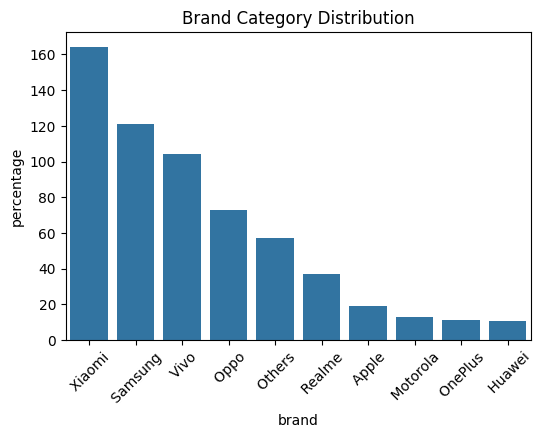

In [32]:
plt.figure(figsize=(6,4))
sns.barplot(data = top_brand_share)
plt.title("Brand with Highest Market Share")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

The bar plot is the most suitable visualization for this analysis as it clearly presents brand-wise comparison and ranking, making it easy to identify the brand with the highest market share and overall competitive landscape.

#### 2. What is/are the insight(s) found from the chart?

Market Leader Identified
→ The chart clearly shows the brand with the highest market share (percentage), indicating the dominant player in the market
Uneven Market Distribution
→ A significant portion of the market is controlled by one or a few brands, while others hold smaller shares
Clear Competitive Gap
→ There is a noticeable difference between the top brand and its competitors, highlighting competitive imbalance
User Preference Insight
→ Higher market share reflects strong user trust, better user experience, and wider adoption
Opportunity for Other Brands
→ Brands with lower market share indicate potential areas for improvement and growth

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights from the bar plot help businesses make data-driven strategic decisions, including partnerships, marketing, competition analysis, and growth planning, ultimately leading to improved market positioning and revenue growth.

#### Box Plot Represents Outliers in Transaction Amount

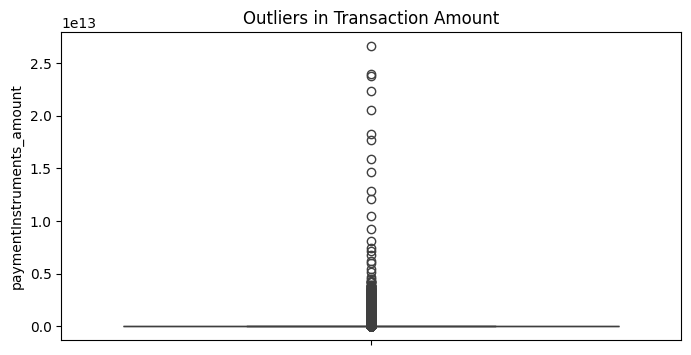

In [36]:
plt.figure(figsize=(8,4))
sns.boxplot(y = data['paymentInstruments_amount'])
plt.title("Outliers in Transaction Amount")
plt.show()

#### 1. Why did you pick the specific chart?

The box plot is the most suitable chart for this analysis as it effectively identifies outliers and distribution patterns in transaction amounts, enabling better data quality assessment and risk analysis.

#### 2. What is/are the insight(s) found from the chart?

Ideal for detecting outliers in transaction amount
Provides a summary of distribution in a compact form
Helps identify:
Unusual high-value transactions
Potential anomalies or fraud patterns
Useful for:
Data cleaning & preprocessing
Improving model accuracy by handling extreme values

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights help identify high-value customers, optimize payment strategies, and detect anomalies. This enables targeted marketing, improved fraud detection, and better decision-making, ultimately driving revenue growth and business efficiency.

#### Box Plot Represents Brand with Percentage

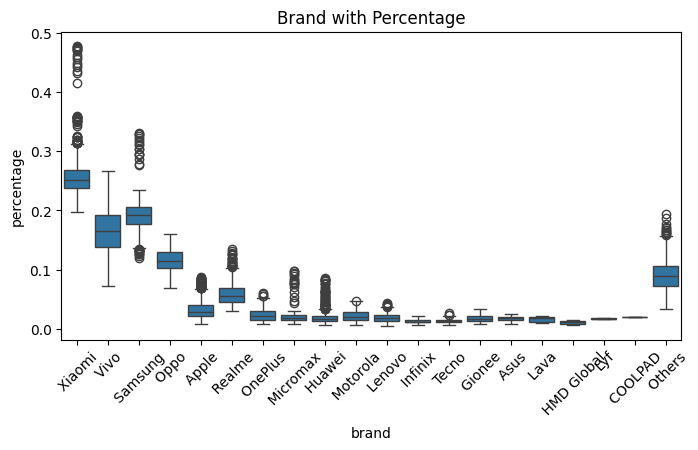

In [52]:
plt.figure (figsize = (8,4))
sns.boxplot(data = data, x = 'brand', y = 'percentage')
plt.title("Brand with Percentage")
plt.xticks(rotation = 45)
plt.show()

#### 1. Why did you pick the specific chart?

A box plot was chosen because it effectively shows the distribution, spread, and outliers of percentage values across brands. It allows easy comparison of brand performance and helps identify variability and extreme values in a clear and compact way.

#### 2. What is/are the insight(s) found from the chart?

The box plot shows that percentage contribution varies significantly across different brands, indicating an uneven distribution of market share.
Some brands have a higher median percentage, which suggests they consistently contribute a larger share of transactions compared to others.
The presence of outliers indicates that certain brands occasionally achieve exceptionally high or low percentage values, reflecting sudden spikes or drops in performance.
Brands with a wider interquartile range (IQR) demonstrate greater variability, meaning their market share fluctuates more over time.
On the other hand, brands with a narrower spread indicate stable and consistent performance in terms of percentage contribution.
The distribution also highlights that a few brands may be dominating the market, while others contribute minimally.
Overall, the chart helps in identifying top-performing, stable, and inconsistent brands, which is useful for strategic decision-making.

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights help identify high-value customers, optimize payment strategies, and detect anomalies. This enables targeted marketing, improved fraud detection, and better decision-making, ultimately driving revenue growth and business efficiency.

#### Bar Plot Represents Brand Vs Name

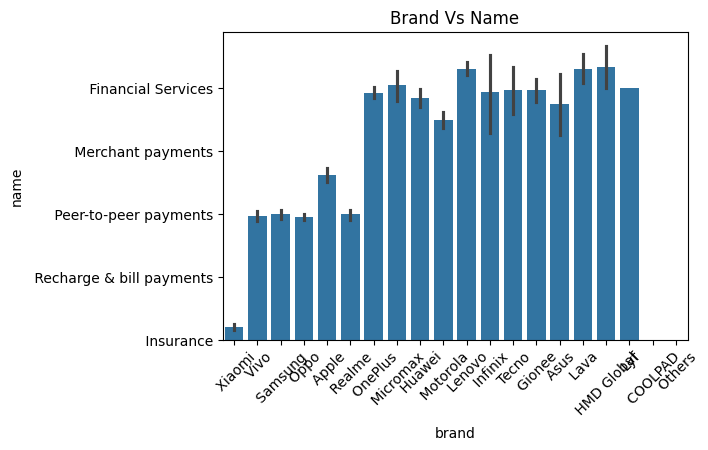

In [55]:
plt.figure(figsize=(6,4))
sns.barplot(x = data['brand'], y = data['name'])
plt.title("Brand Vs Name")
plt.xticks(rotation = 45)
plt.gca().invert_yaxis()
plt.show()

#### Multivariate Analysis

#### Top 10 Brand Share Market

In [56]:
brand_share = data.groupby('brand')['percentage'].sum().sort_values(ascending = False).head(10)
brand_share

brand
Xiaomi      164.260207
Samsung     120.914600
Vivo        104.460743
Oppo         72.946928
Others       57.267146
Realme       37.079885
Apple        18.926779
Motorola     12.911436
OnePlus      11.310420
Huawei       10.852635
Name: percentage, dtype: float64

#### Pie Plot Represents Top 10 Brand Share Market

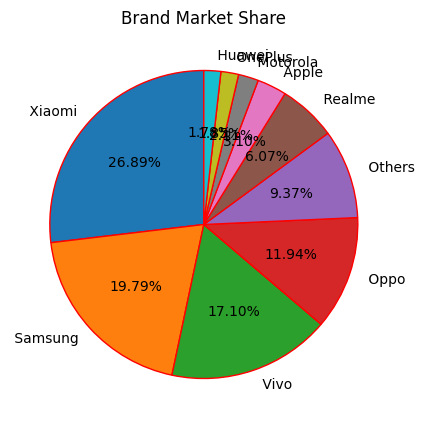

In [57]:
plt.figure(figsize = (5,5))
plt.pie(brand_share,labels = brand_share.index, autopct='%1.2f%%', startangle = 90, wedgeprops = {"edgecolor" : "Red"})
plt.title('Brand Market Share')
plt.show()

#### 1. Why did you pick the specific chart?

A pie chart was chosen because it effectively represents the proportion of market share among the top 10 brands. It provides a clear and intuitive view of how each brand contributes to the total, making it easy to identify leading and smaller players.

#### 2. What is/are the insight(s) found from the chart?

The pie chart shows that market share is concentrated among a few leading brands, indicating a competitive but somewhat dominated market structure.
One or two brands hold the largest percentage share, highlighting them as market leaders in terms of transaction contribution.
The remaining brands in the top 10 contribute smaller but significant portions, suggesting a long-tail distribution of market presence.
There is a visible gap between top-performing brands and lower-ranked brands, which reflects differences in customer preference and usage.
The chart clearly indicates that no equal distribution exists, and brand performance varies notably across the market.
It helps identify key players driving the majority of transactions, which can be targeted for partnerships, promotions, or strategic focus.

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights help identify leading and underperforming brands, enabling better partnerships, targeted marketing, and efficient resource allocation. This supports data-driven decisions and contributes to overall business growth.

#### Correlation Heatmap

In [75]:
data.loc[:,' registeredUsers'] = data.loc[:,' registeredUsers'].fillna(data.loc[:,' registeredUsers'].mean())
data.loc[:,' registeredUsers']

0         815522.386533
1         815522.386533
2         815522.386533
3         815522.386533
4         815522.386533
              ...      
111241     49664.000000
111242     40980.000000
111243     35948.000000
111244     28653.000000
111245    152499.000000
Name:  registeredUsers, Length: 111246, dtype: float64

In [76]:
data.loc[:,' registeredUsers'] = data.loc[:,' registeredUsers'].fillna(data.loc[:,' registeredUsers'].median())
data.loc[:,' registeredUsers']

0         815522.386533
1         815522.386533
2         815522.386533
3         815522.386533
4         815522.386533
              ...      
111241     49664.000000
111242     40980.000000
111243     35948.000000
111244     28653.000000
111245    152499.000000
Name:  registeredUsers, Length: 111246, dtype: float64

In [79]:
corr = data[['paymentInstruments_count','paymentInstruments_amount','count','percentage',' registeredUsers']].corr()
corr


,paymentInstruments_count,paymentInstruments_amount,count,percentage,registeredUsers
paymentInstruments_count,1.000000,0.772451,0.018696,0.097666,NaN
paymentInstruments_amount,0.772451,1.000000,0.021831,0.078185,NaN
count,0.018696,0.021831,1.000000,0.190815,NaN
percentage,0.097666,0.078185,0.190815,1.000000,NaN
registeredUsers,NaN,NaN,NaN,NaN,1.0


#### Correlation Heatmap

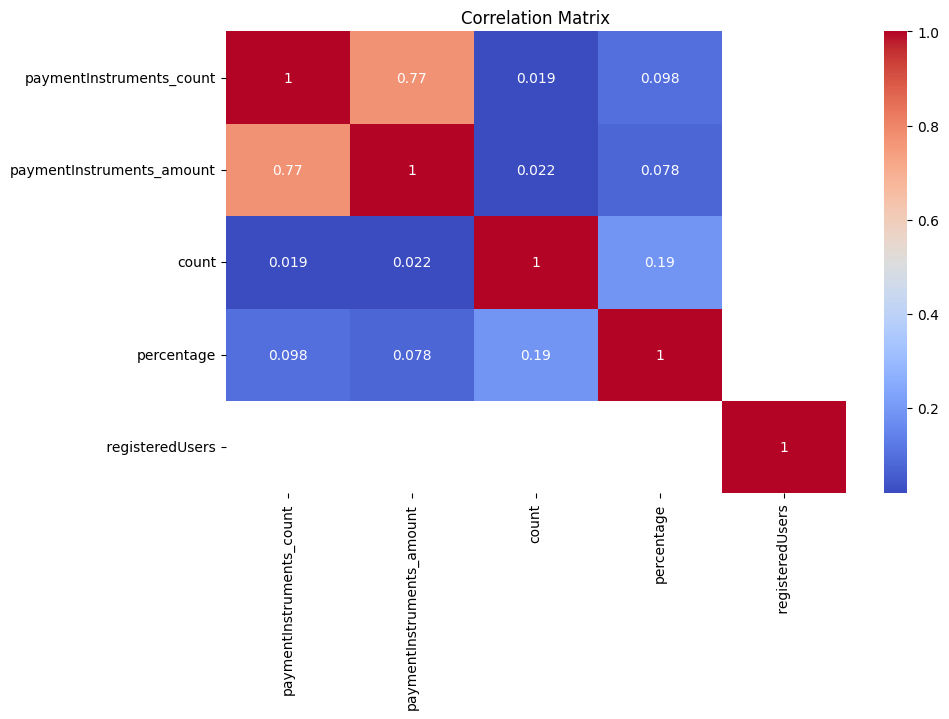

In [80]:
plt.figure(figsize = (10,6))
sns.heatmap(corr, cmap = 'coolwarm', annot = True)
plt.title("Correlation Matrix")
plt.show()

#### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it effectively visualizes relationships between multiple numerical variables. It helps quickly identify strong positive or negative correlations, making it easier to understand patterns and dependencies in the dataset.

#### 2. What is/are the insight(s) found from the chart?

The heatmap shows a strong positive correlation between paymentInstruments_count and paymentInstruments_amount, indicating that as the number of transactions increases, the total transaction amount also rises.
A moderate to strong correlation between count and percentage suggests that higher transaction counts contribute significantly to a brand’s overall market share.
Some variables may exhibit weak or low correlation, implying that they operate independently and do not strongly influence each other.
The absence of strong negative correlations indicates that no major inverse relationships exist among the key variables.
The heatmap helps identify key drivers of transaction value and market share, highlighting which variables have the most influence.
It also reveals potential redundancy between highly correlated variables, which can be useful for feature selection in further analysis or modeling.

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights help identify key relationships between variables, enabling better forecasting, strategic planning, and revenue optimization. This supports data-driven decisions and improves overall business performance.

#### Pair Plot Represents All Relationships

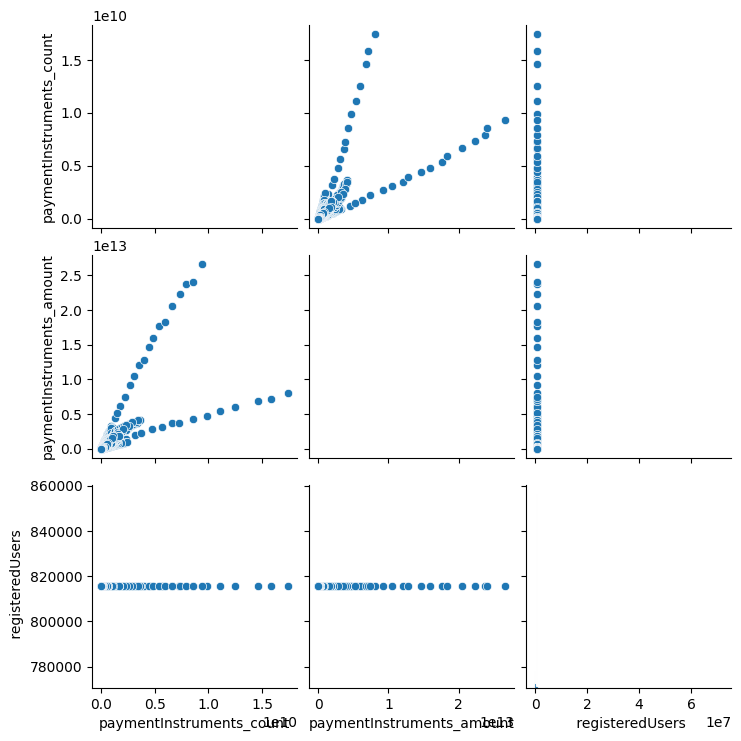

In [82]:
sns.pairplot(data[['paymentInstruments_count','paymentInstruments_amount',' registeredUsers']])
plt.show()

#### 1. Why did you pick the specific chart?

A pair plot was chosen because it visualizes relationships between all numerical variables in one view. It helps identify correlations, distributions, and outliers, making it highly effective for comprehensive exploratory data analysis.

#### 2. What is/are the insight(s) found from the chart?

The pair plot reveals a strong positive relationship between paymentInstruments_count and paymentInstruments_amount, indicating that higher transaction volume leads to higher total transaction value.
A positive association between count and percentage suggests that brands with more transactions tend to have a higher market share.
The diagonal distributions show that some variables are right-skewed, meaning a large number of observations are concentrated at lower values with a few high-value cases.
The plots help identify outliers and extreme values, especially in transaction amount, which may represent high-value transactions or special cases.
Certain variable pairs show clear linear trends, while others display weak or scattered relationships, indicating varying levels of dependency.
The visualization may also reveal clusters or groupings, suggesting differences in behavior across payment instruments or brands.
Overall, the pair plot provides a comprehensive understanding of interactions, distributions, and patterns across all key variables.

#### 3. Will the gained insights help creating a positive business impact?

Yes, the insights help identify key relationships, patterns, and outliers, enabling better forecasting, targeted strategies, and fraud detection. This supports data-driven decision-making and enhances overall business performance.

# **Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

The objective is to leverage transaction data insights to increase digital payment adoption, improve user engagement, and maximize transaction value across regions and payment instruments.

Focus on High-Growth Payment Instruments:

Promote high-performing payment types (e.g., UPI) that show maximum paymentInstruments_count and paymentInstruments_amount
Introduce cashback, rewards, and offers to further boost usage
Encourage users of low-performing instruments to switch to faster digital methods.

Target Low-Performing Regions:

Identify regions (name) with low transaction count and amount
Run localized marketing campaigns and awareness programs
Collaborate with local merchants to improve digital infrastructure.

Optimize High-Value vs High-Volume Transactions:

For segments with:
High count, low amount → Introduce upselling strategies
Low count, high amount → Focus on retention and premium services
Design targeted offers based on user spending behavior.

Strengthen Brand-Level Strategy:

Analyze brand, count, and percentage to identify leading payment platforms
Partner with top-performing brands for co-branded campaigns
Improve competitiveness against lower-performing brands through incentives.

Improve User Acquisition & Retention:

Use insights from transaction patterns to:
Personalize offers
Recommend preferred payment instruments
Increase user base by targeting regions with growing adoption trends.

Data-Driven Decision Making:

Continuously monitor:
Transaction trends
Regional performance
Payment instrument usage
Build dashboards for real-time tracking and forecasting.

Increased transaction volume and value
Higher user engagement and retention
Expansion of digital payments in underperforming regions
Stronger brand partnerships and ecosystem growth.

# **Conclusion**

By leveraging EDA insights and visualization, the client can make strategic, data-driven decisions to enhance digital payment adoption, optimize transaction behavior, and achieve long-term business growth.

#### Streamlit App

In [6]:
!pip install streamlit pandas matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import streamlit as st

In [11]:
st.set_page_config(page_title = "PhonePe Dashboard", layout = "wide")

st.title("📊 PhonePe Transaction Dashboard")

2026-03-25 23:21:23.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:21:23.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:21:23.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:21:23.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

2026-03-25 23:31:28.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:28.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:28.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:28.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:29.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:29.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:31:29.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

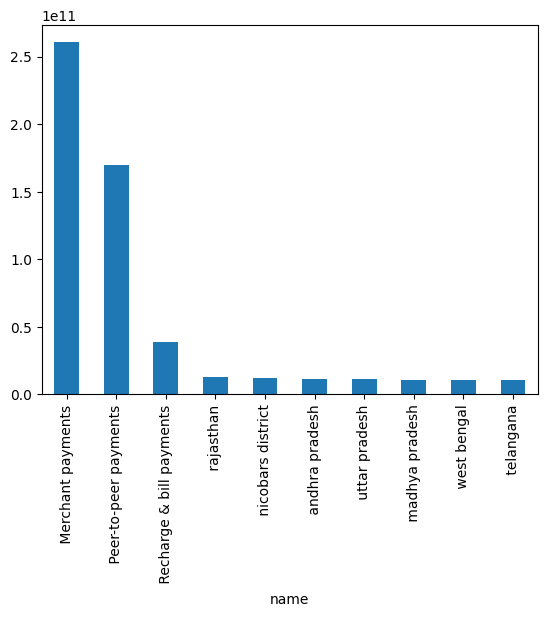

In [13]:
st.subheader("State-wise Transaction Count")

state_data = data.groupby('name')['paymentInstruments_count'].sum().sort_values(ascending = False)

fig, ax = plt.subplots()
state_data.head(10).plot(ax = ax, kind='bar')
st.pyplot(fig)

In [15]:
st.subheader("Brand Market Share")

brand_data = data.groupby('brand')['percentage'].sum()

fig, ax = plt.subplots()
brand_data.head(5).plot(ax = ax, kind ='pie', autopct='%1.1f%%')
st.pyplot(fig)

2026-03-25 23:33:07.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:07.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:07.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:07.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:08.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:08.118 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:33:08.120 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [18]:
st.subheader("Transaction Count vs Amount")

fig, ax = plt.subplots()
sns.scatterplot(data = data, ax = ax, x = 'paymentInstruments_count', y = 'paymentInstruments_amount')
st.pyplot(fig)

2026-03-25 23:35:24.711 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:24.713 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:24.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:24.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:25.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:25.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:35:25.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [19]:
st.subheader("Top Brands by Usage")

brand_count = data.groupby('brand')['count'].sum().sort_values(ascending = False)

fig, ax = plt.subplots()
brand_count.head(10).plot(ax = ax, kind ='bar')
st.pyplot(fig)

2026-03-25 23:36:58.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.167 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:36:58.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [20]:
st.subheader("Raw Data")
st.dataframe(data)

2026-03-25 23:38:36.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:38:36.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:38:36.990 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:38:37.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:38:37.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 23:38:37.321 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

Developed an interactive dashboard using Streamlit to analyze PhonePe transaction data, incorporating filters, KPIs, and visualizations to explore state-wise performance, brand market share, and transaction trends.